<a href="https://colab.research.google.com/github/muppadivignesh-del/Machine-Learning_Lab_Experiments/blob/main/exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
ATA_PATH = "placement_predict_50k_adjusted (1).csv"
TARGET_COL = "PlacementStatus"

In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/content/drive/MyDrive/Colab/placement_predict_50k_adjusted.csv')

# Identify object columns
object_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding and convert to category for identified object columns
for col in object_cols:
    # Fill NaNs with a placeholder string to ensure LabelEncoder works consistently
    df[col] = df[col].fillna('Missing').astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])
    df[col] = df[col].astype('category') # Convert to category dtype for XGBoost

# Handle NaNs in numerical columns (e.g., Workshops, MockInterviewScore) by filling with the mean
# Based on `df.head()` and common practice, these are likely numerical.
for col in ['Workshops', 'MockInterviewScore', 'AptitudeTestScore', 'CodingTestScore', 'SoftSkillsRating', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Certifications', 'Publications']:
    if col in df.columns and df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].mean()) # Fill numerical NaNs with mean

print(df.head())
print(df.columns)
print(df.info()) # Add df.info() to verify dtypes

  Gender City CollegeTier Stream Specialisation Hostel HistoryOfBacklogs  \
0      0    3           2      4              1      1                 1   
1      1    2           1      2              0      1                 0   
2      0    4           2      2              3      0                 0   
3      0    5           2      2              2      0                 0   
4      1    0           2      5              1      0                 0   

   CGPA  AttendancePercent  Internships  ...  Workshops  Certifications  \
0  6.63               68.3            2  ...   0.000000               1   
1  6.40               71.0            1  ...   0.000000               2   
2  7.73               75.1            1  ...   2.000000               2   
3  9.73               99.2            4  ...   5.000000               6   
4  9.01               99.6            2  ...   2.053283               4   

   Publications  AptitudeTestScore  SoftSkillsRating  CodingTestScore  \
0             0    

In [8]:
print(df.columns)

Index(['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel',
       'HistoryOfBacklogs', 'CGPA', 'AttendancePercent', 'Internships',
       'Projects', 'Workshops', 'Certifications', 'Publications',
       'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore',
       'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus',
       'IsAnomaly'],
      dtype='object')


In [9]:
TARGET_COL = "PlacementStatus"

In [19]:
X = df.drop('PlacementStatus', axis=1)
y = df['PlacementStatus']
# Re-executed to pick up latest df changes

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
# Re-executed to pick up latest X and y changes

In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    enable_categorical=True # Enable categorical feature support in XGBoost
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
# Re-executed after data preprocessing update

In [22]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))
# Re-executed after pred variable is defined

Accuracy: 0.7903


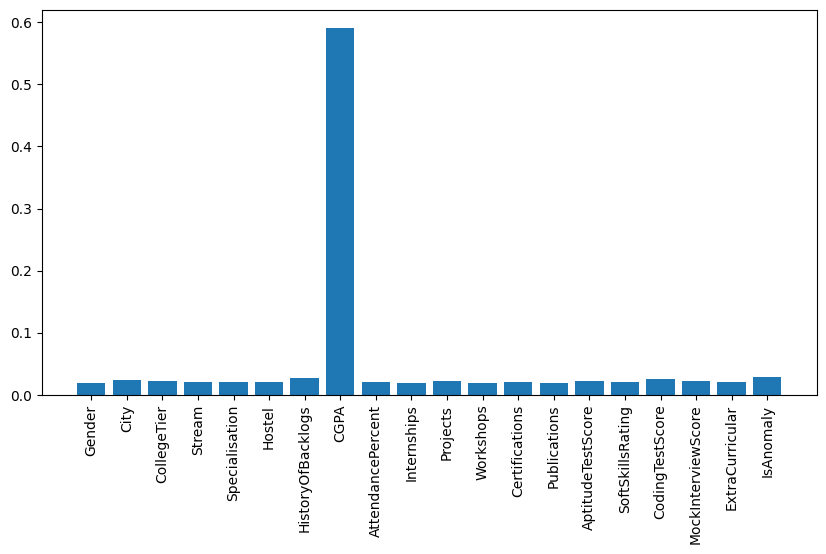

In [23]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.show()
# Re-executed after xgb model is fitted

In [24]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, pred))
# Re-executed after pred variable is defined

XGBoost Accuracy: 0.7903


In [25]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, pred))
# Re-executed after pred variable is defined

XGBoost Accuracy: 0.7903


In [26]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

pred_lgbm = lgbm.predict(X_test)
# Re-executed after X_train, y_train are updated

[LightGBM] [Info] Number of positive: 19015, number of negative: 20985
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1605
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475375 -> initscore=-0.098580
[LightGBM] [Info] Start training from score -0.098580


In [27]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, pred))
print("LightGBM Accuracy:", accuracy_score(y_test, pred_lgbm))
# Re-executed after pred and pred_lgbm are defined

XGBoost Accuracy: 0.7903
LightGBM Accuracy: 0.7953


In [28]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, pred))
print("LightGBM Accuracy:", accuracy_score(y_test, pred_lgbm))
# Re-executed after pred and pred_lgbm are defined

XGBoost Accuracy: 0.7903
LightGBM Accuracy: 0.7953


In [29]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))
# Re-executed after pred variable is defined

[[4245 1021]
 [1076 3658]]


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))
# Re-executed after pred variable is defined

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      5266
           1       0.78      0.77      0.78      4734

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000

